![Sleep Health and Lifestyle Banner](banner_image.png)

# Sleep Health and Lifestyle

This synthetic dataset contains sleep and cardiovascular metrics as well as lifestyle factors of close to 400 fictive persons.

The workspace is set up with one CSV file, `data.csv`, with the following columns:

- `Person ID`
- `Gender`
- `Age`
- `Occupation`
- `Sleep Duration`: Average number of hours of sleep per day
- `Quality of Sleep`: A subjective rating on a 1-10 scale
- `Physical Activity Level`: Average number of minutes the person engages in physical activity daily
- `Stress Level`: A subjective rating on a 1-10 scale
- `BMI Category`
- `Blood Pressure`: Indicated as systolic pressure over diastolic pressure
- `Heart Rate`: In beats per minute
- `Daily Steps`
- `Sleep Disorder`: One of `None`, `Insomnia` or `Sleep Apnea`

Check out the guiding questions or the scenario described below to get started with this dataset!
Feel free to make this workspace yours by adding and removing cells, or editing any of the existing cells.

Source: [Kaggle](https://www.kaggle.com/datasets/uom190346a/sleep-health-and-lifestyle-dataset/)

### 🌎 **Some guiding questions to help you explore this data:**

1. Which factors could contribute to a sleep disorder?
2. Does an increased physical activity level result in a better quality of sleep?
3. Does the presence of a sleep disorder affect the subjective sleep quality metric?

In [2]:
SELECT *
FROM 'data.csv'

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,None
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,None
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,None
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
...,...,...,...,...,...,...,...,...,...,...,...,...,...
369,370,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
370,371,Female,59,Nurse,8.0,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
371,372,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
372,373,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [4]:
sleep_data = pd.read_csv('data.csv')
sleep_data

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
...,...,...,...,...,...,...,...,...,...,...,...,...,...
369,370,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
370,371,Female,59,Nurse,8.0,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
371,372,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
372,373,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea


### Data Exploration

In [5]:
sleep_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 38.1+ KB


In [6]:
# explore the categorical variables
categorical_cols = sleep_data.select_dtypes(include=['object', 'category']).columns.tolist()

for col in categorical_cols:
    print(sleep_data[col].value_counts())

Gender
Male      189
Female    185
Name: count, dtype: int64
Occupation
Nurse                   73
Doctor                  71
Engineer                63
Lawyer                  47
Teacher                 40
Accountant              37
Salesperson             32
Scientist                4
Software Engineer        4
Sales Representative     2
Manager                  1
Name: count, dtype: int64
BMI Category
Normal           195
Overweight       148
Normal Weight     21
Obese             10
Name: count, dtype: int64
Blood Pressure
130/85    99
140/95    65
125/80    65
120/80    45
115/75    32
135/90    27
140/90     4
125/82     4
128/85     3
132/87     3
117/76     2
130/86     2
126/83     2
119/77     2
135/88     2
128/84     2
131/86     2
139/91     2
115/78     2
129/84     2
142/92     2
118/75     2
118/76     1
122/80     1
121/79     1
Name: count, dtype: int64
Sleep Disorder
Sleep Apnea    78
Insomnia       77
Name: count, dtype: int64


### Data Cleaning

In [7]:
# fix BMI categories
sleep_data['BMI Category'] = sleep_data['BMI Category'].replace('Normal Weight', 'Normal')
sleep_data['BMI Category'].value_counts()

BMI Category
Normal        216
Overweight    148
Obese          10
Name: count, dtype: int64

In [8]:
# fill missing values 
sleep_data['Sleep Disorder'] = sleep_data['Sleep Disorder'].fillna('None')
sleep_data['Sleep Disorder'].value_counts()

Sleep Disorder
None           219
Sleep Apnea     78
Insomnia        77
Name: count, dtype: int64

## Which factors could contribute to a sleep disorder?

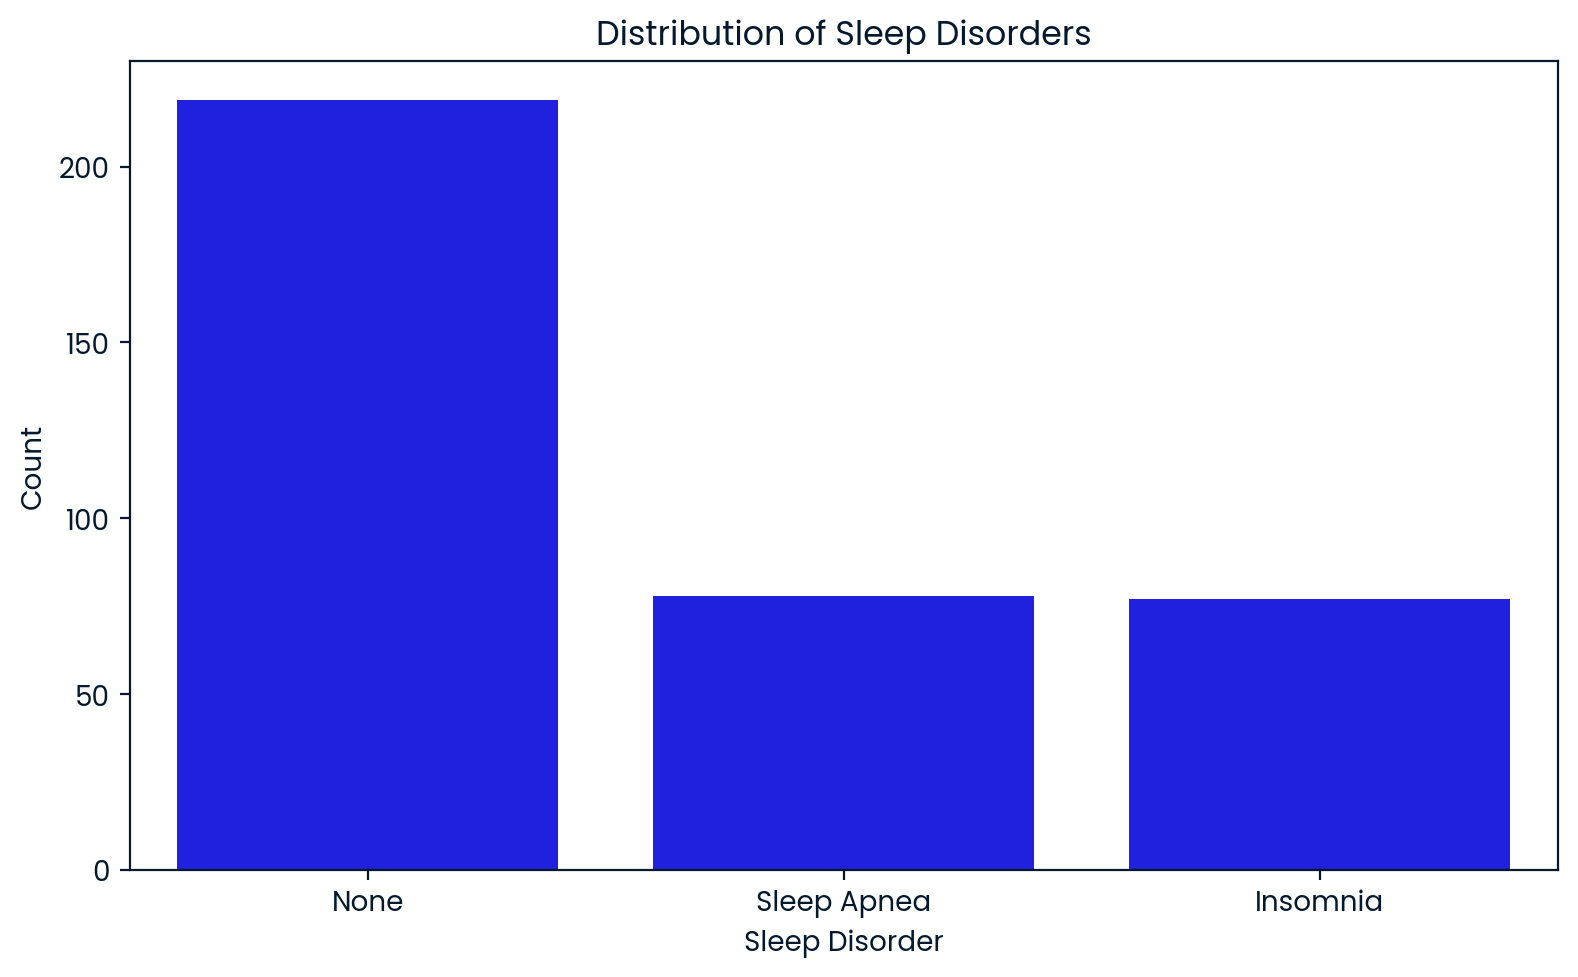

In [9]:
plt.figure(figsize=(8, 5))
sns.countplot(data=sleep_data, x='Sleep Disorder', order=sleep_data['Sleep Disorder'].value_counts().index, color='blue')
plt.title('Distribution of Sleep Disorders')
plt.xlabel('Sleep Disorder')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [10]:
# Identify numerical and categorical columns
numerical_cols = sleep_data.select_dtypes(include=['float64', 'int64']).columns.tolist()
categorical_cols = sleep_data.select_dtypes(include=['object', 'category']).columns.tolist()

# Remove 'Sleep Disorder' from categorical columns for analysis
categorical_cols.remove('Sleep Disorder')

# Remove 'Patient ID' from numerical columns
numerical_cols.remove('Person ID')

# Correlation between numerical features and sleep disorder presence
sleep_data['Has_Disorder'] = (sleep_data['Sleep Disorder'] != 'None').astype(int)
numerical_corr = sleep_data[numerical_cols + ['Has_Disorder']].corr().round(2)['Has_Disorder'].drop(['Has_Disorder'])

# Display correlations
from IPython.display import display
print('Correlation between numerical features and sleep disorder presence:')
display(numerical_corr)


Correlation between numerical features and sleep disorder presence:


Age                        0.43
Sleep Duration            -0.34
Quality of Sleep          -0.31
Physical Activity Level    0.07
Stress Level               0.18
Heart Rate                 0.33
Daily Steps               -0.03
Name: Has_Disorder, dtype: float64

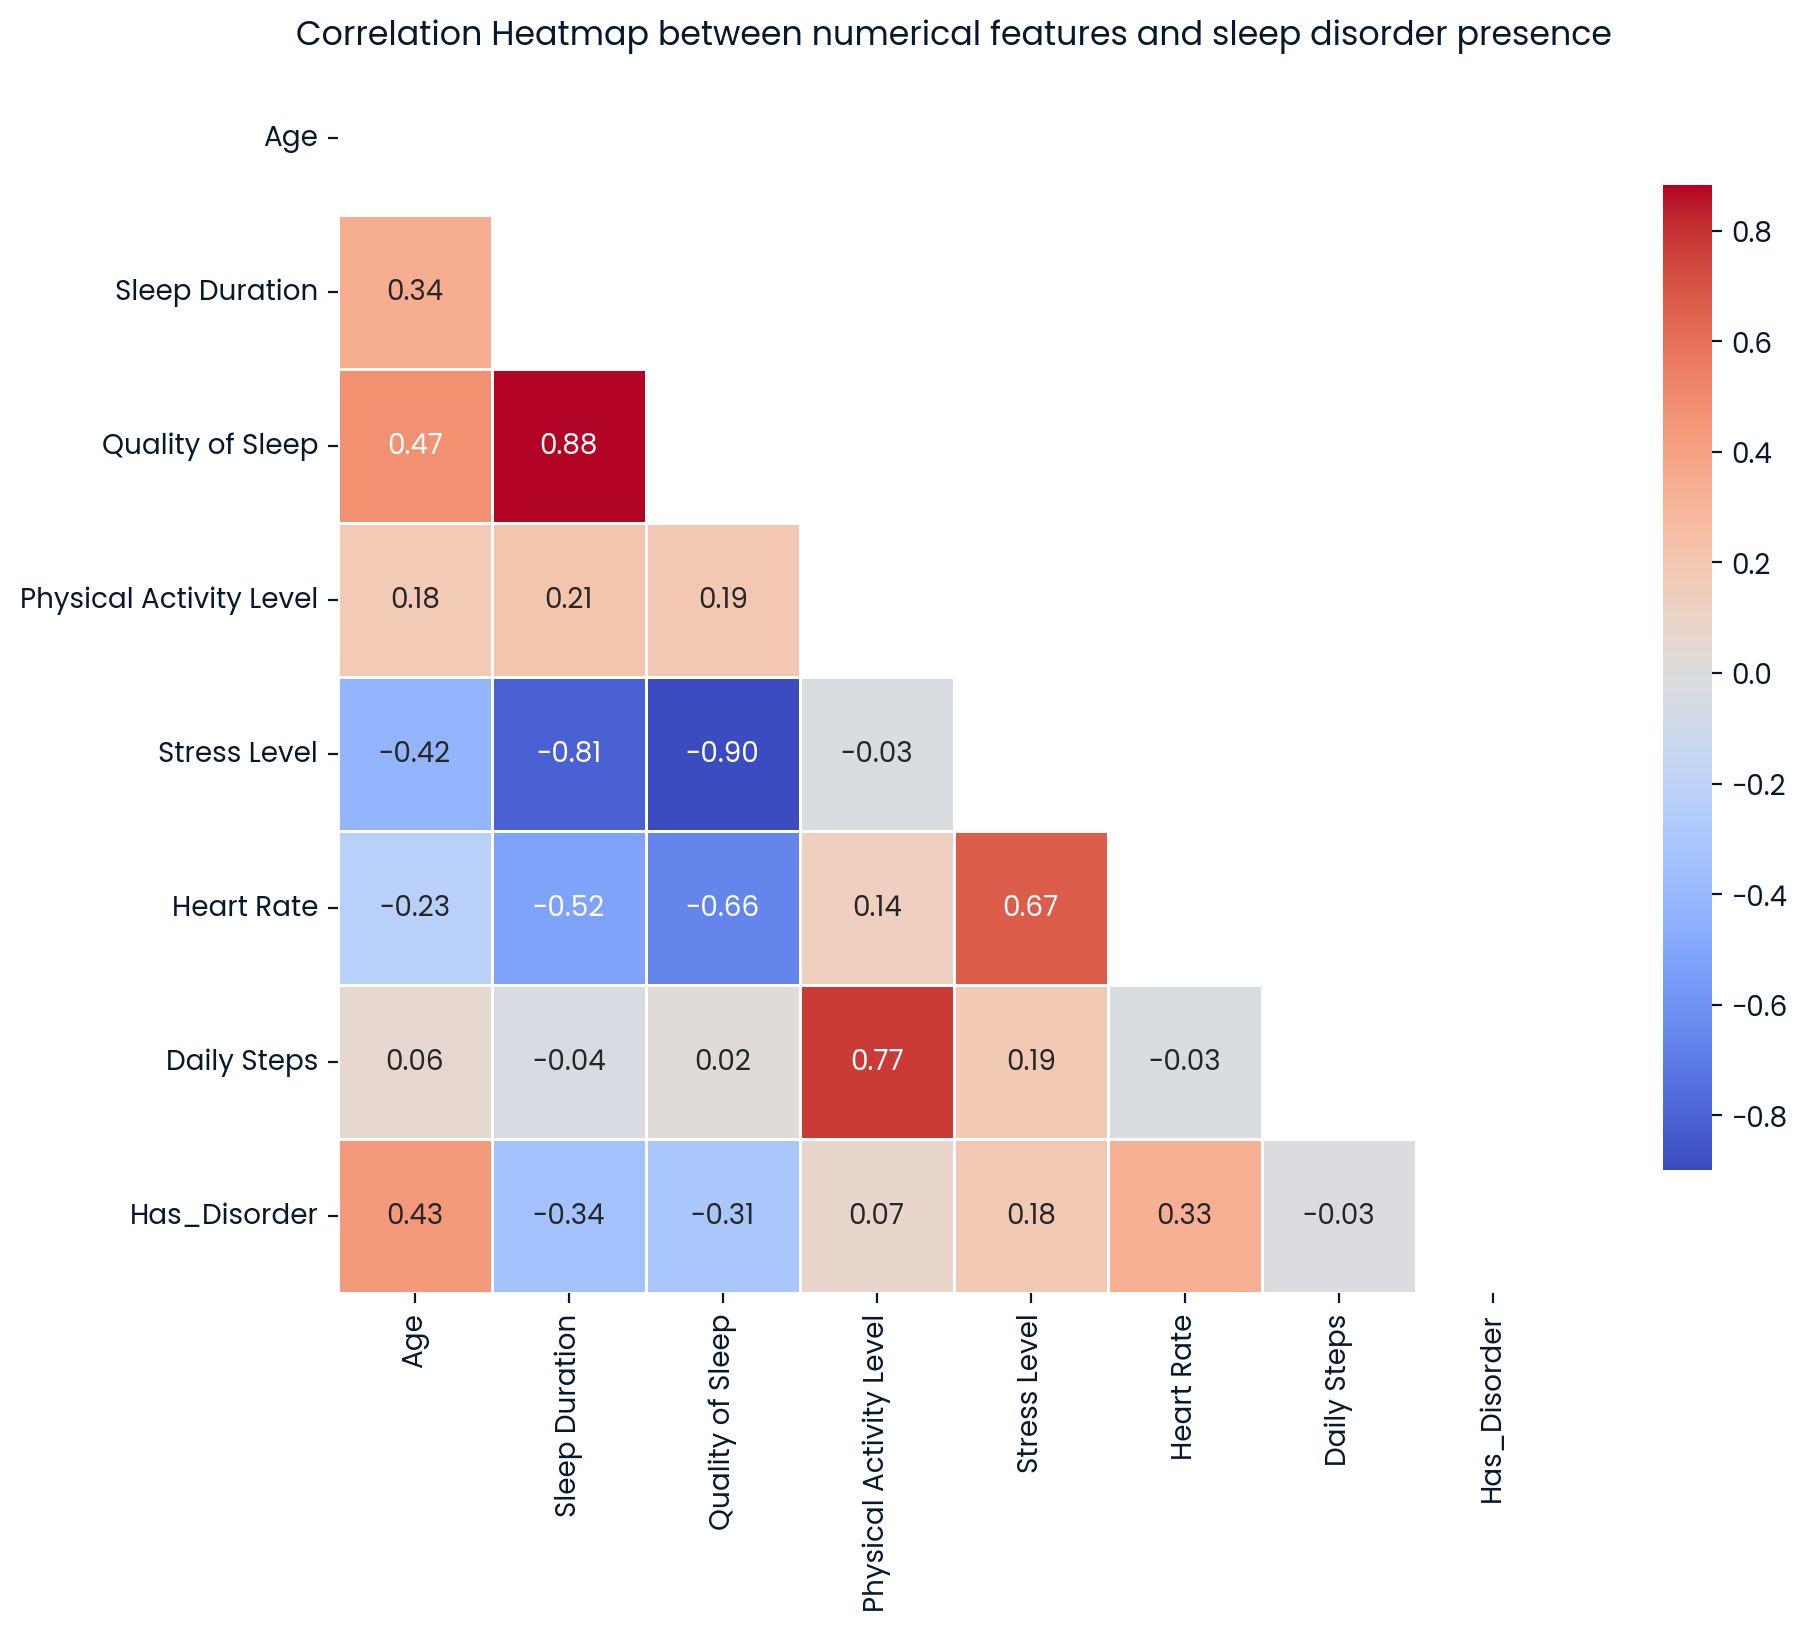

In [11]:
corr = sleep_data[numerical_cols + ['Has_Disorder']].corr()

# Generate a mask for the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(12, 8))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', square=True, linewidths=.5, cbar_kws={"shrink": .8})
plt.title('Correlation Heatmap between numerical features and sleep disorder presence')
plt.show()

In a correlation matrix, the values range from $-1$ to $1$. The closer the number is to the absolute value of $1$, the stronger the relationship.

The heatmap above shows the pearson correlation of the numerical variables with eachother. It shows there's a weak to moderate relationship between numerical features and sleep disorder presence.

**Moderate correlation**:
- Age ($0.43$): This is the strongest positive correlation. It suggests that as Age increases, the likelihood of having a sleep disorder also increases.
- Sleep Duration ($-0.34$): A negative correlation indicates that as Sleep Duration goes up, the presence of a disorder goes down. This makes intuitive sense, as people with disorders often struggle to maintain long sleep periods.
- Heart Rate ($0.33$): There is a moderate positive link here. A higher resting heart rate appears associated with the presence of a sleep disorder, which could be a physiological symptom of conditions like sleep apnea or high stress.
- Quality of Sleep ($-0.31$): Similar to duration, higher subjective rating is associated with a lower chance of having a disorder.

**Weak correlation**:
- Stress Level ($0.18$): While positive, this is surprisingly weak. It suggests that while stress is a factor, it isn't a definitive linear predictor of a disorder on its own in this group.
- Physical Activity ($0.07$) & Daily Steps ($-0.03$): These are nearly zero. This implies that, at least linearly, how much someone moves during the day doesn't directly tell us if they have a clinical sleep disorder.

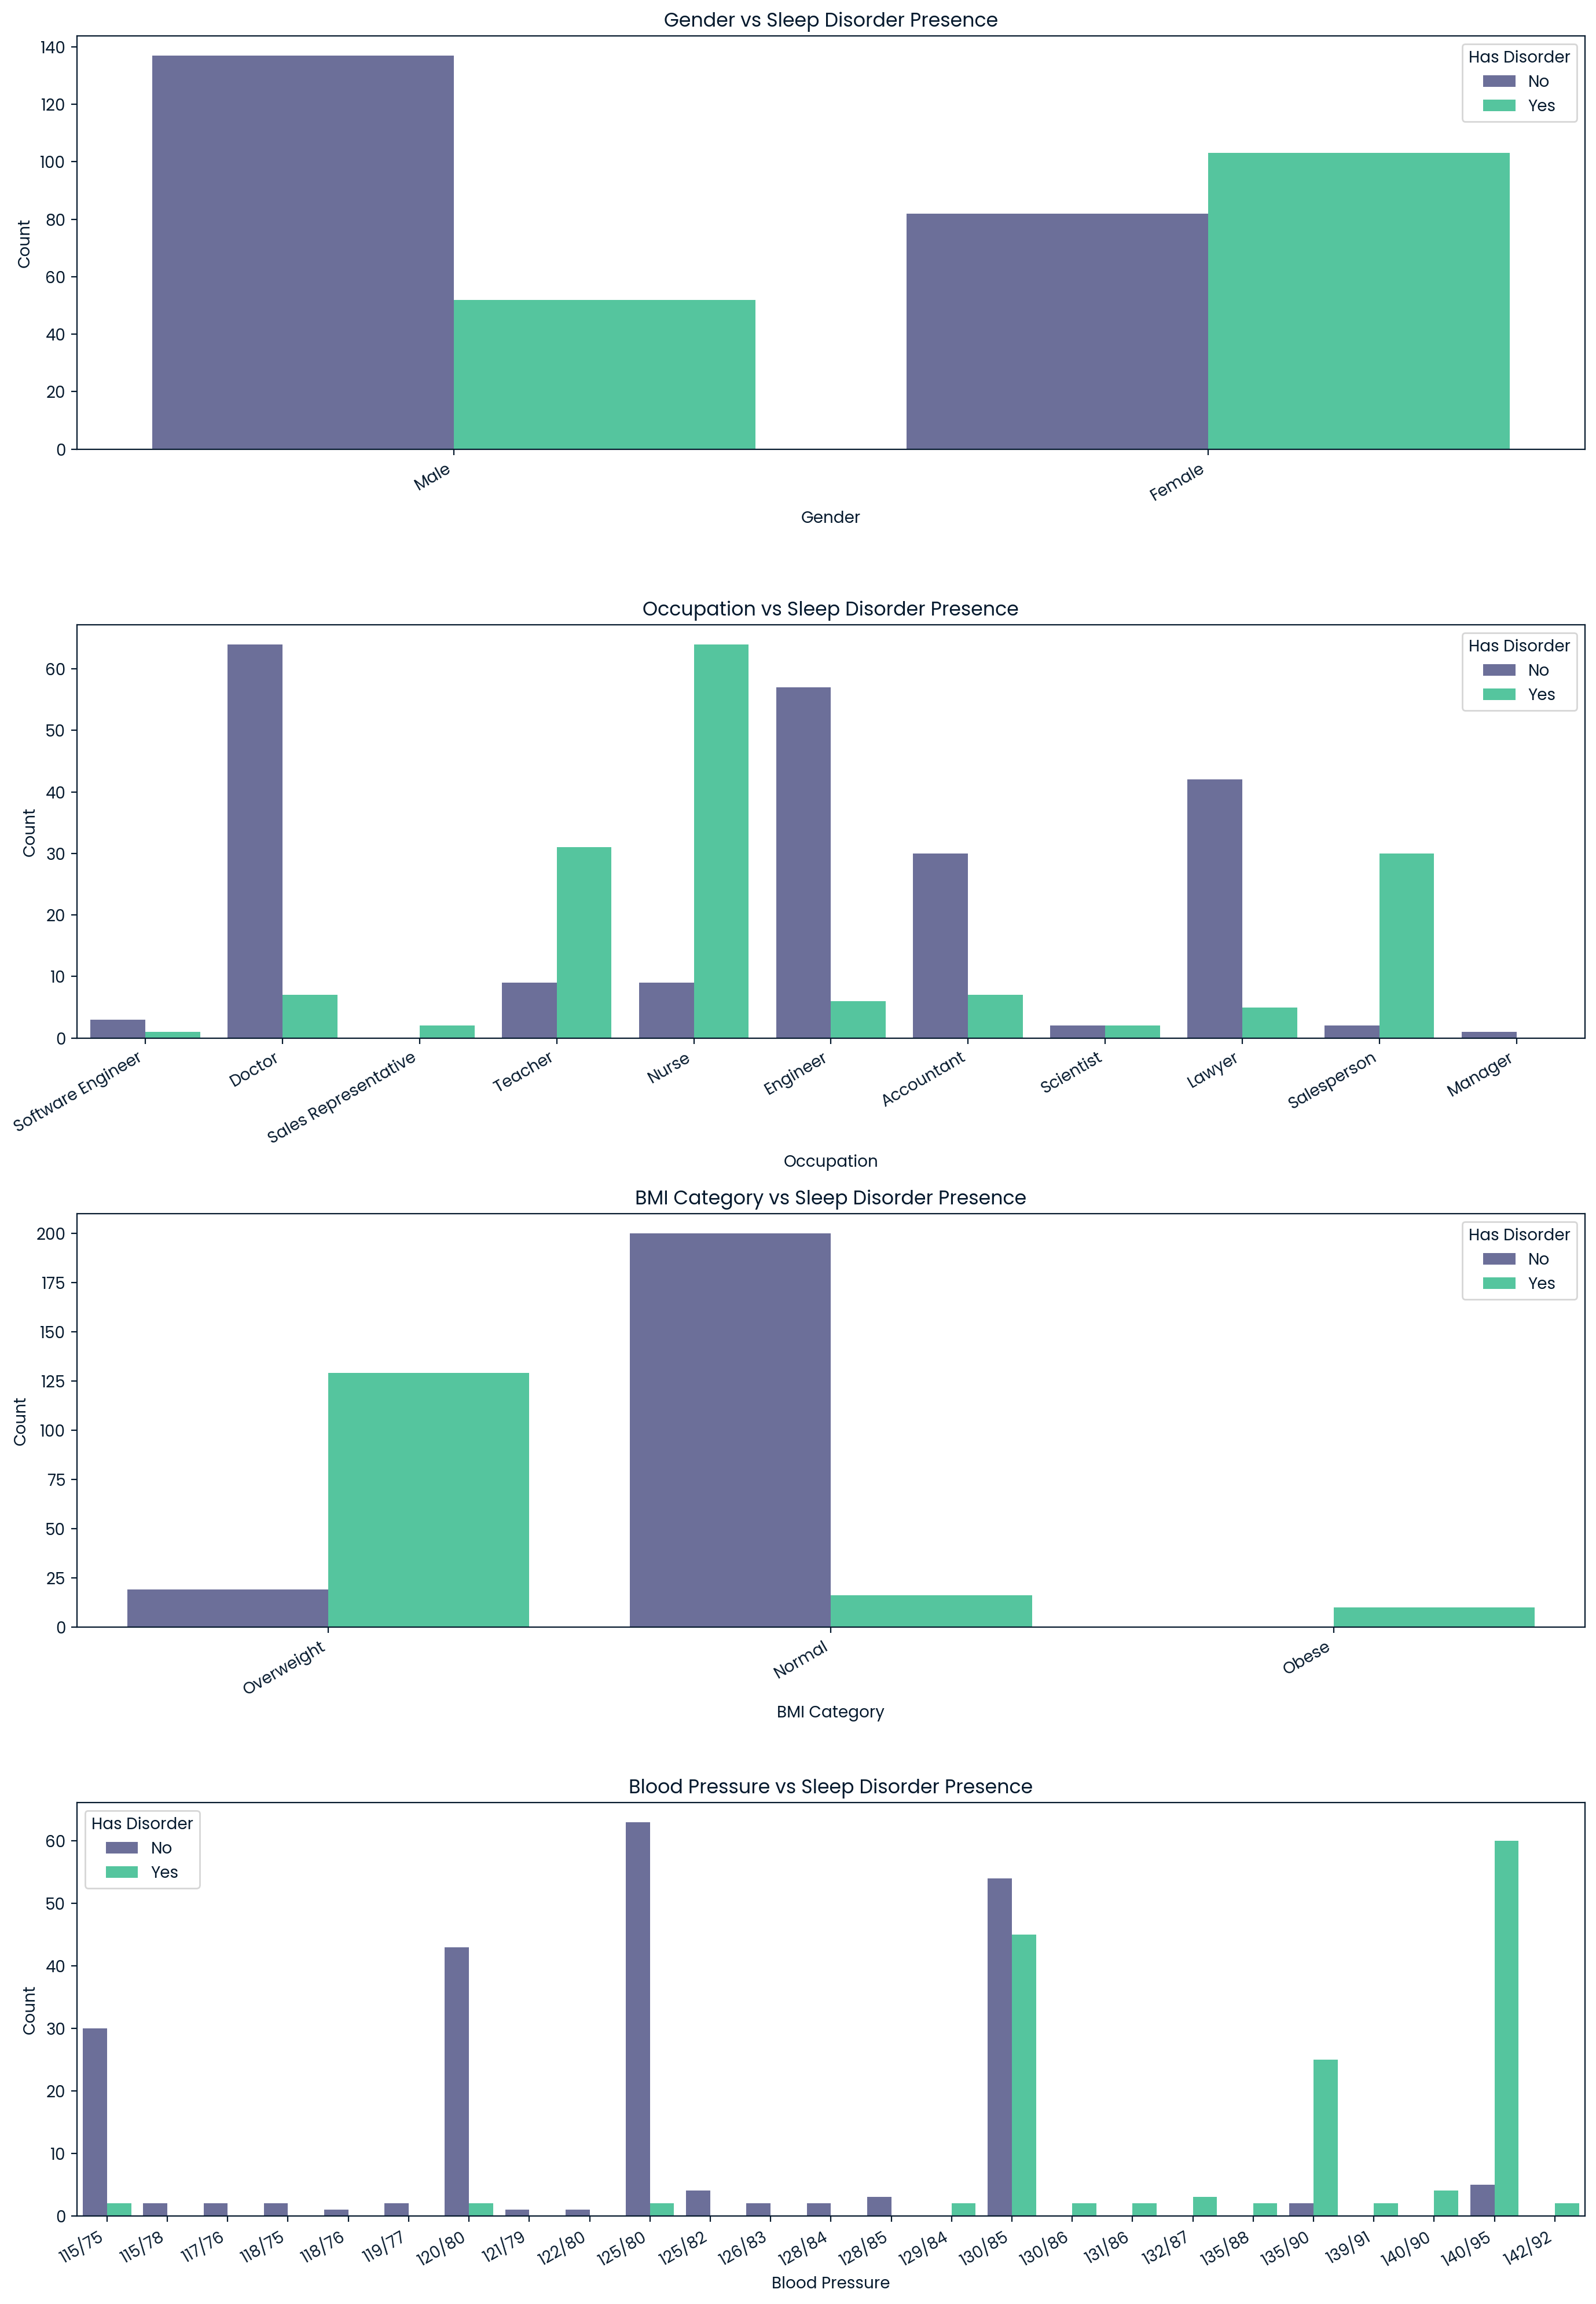

In [12]:
# Ensure Blood Pressure is plotted in ascending order
bp_order = None
if 'Blood Pressure' in categorical_cols:
    # Try to sort blood pressure values numerically if possible
    try:
        # Remove non-numeric characters and sort
        bp_order = sorted(sleep_data['Blood Pressure'].dropna().unique(), key=lambda x: [int(s) for s in str(x).replace('/', ' ').split()])
    except Exception:
        # Fallback to string sort
        bp_order = sorted(sleep_data['Blood Pressure'].dropna().unique())

n_cols = 1
n_rows = len(categorical_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5 * n_rows), squeeze=False)

for idx, col in enumerate(categorical_cols):
    ax = axes[idx, 0]
    order = None
    if col == 'Blood Pressure' and bp_order is not None:
        order = bp_order
    sns.countplot(data=sleep_data, x=col, hue='Has_Disorder', ax=ax, order=order)
    ax.set_title(f'{col} vs Sleep Disorder Presence')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.legend(title='Has Disorder', labels=['No', 'Yes'])
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.show()

These countplots provide a much clearer picture of the categorical factors contributing to sleep disorders, and reveal risk clusters.

1. Gender: The Female Prevalence
   - Males: A significantly higher number of men in this dataset do not have a sleep disorder.
   - Females: In contrast, the "Yes" count for females exceeds the "No" count.
     
   Insight: In this specific population, being female is associated with a higher likelihood of reported sleep disorders.


2. Occupation: High-Risk Professions. The data suggests that the nature of one's work plays a massive role:
   - High Risk: Nurses, Teachers, and Salespeople show a higher count of "Yes" than "No." Nurses, in particular, show a very high prevalence, possibly due to shift work or high-stress environments.
   - Low Risk: Doctors, Engineers, Accountants, and Lawyers have a much higher proportion of individuals without disorders.

   Insight: Lifestyle factors associated with specific careers (stress, irregular hours, activity levels) are likely contributing factors.


3. BMI Category: The relationship here is striking.
   - Normal Weight: The vast majority of individuals in this category do not have a sleep disorder.
   - Overweight: There are significantly more people with a sleep disorder than without in this group.
   - Obese: Although the sample size is smaller, nearly every individual in this category is marked as having a sleep disorder.

   Insight: BMI is one of the strongest categorical predictors in your dataset.


4. Blood Pressure: The distribution shows a clear "cutoff" where sleep disorders become common:
   - Low/Normal BP (e.g., 115/75 to 125/80): These groups are dominated by individuals without sleep disorders.
   - Elevated BP (130/85 and 140/95): At these specific readings, the "Yes" bars surge. Specifically, the 140/95 group is almost entirely composed of individuals with a sleep disorder.
   
   Insight: There is a strong physiological link here, likely reflecting how conditions like Sleep Apnea can drive up blood pressure.

Based on the visualizations (heatmap + bar charts), the factors contributing to sleep disorders include:

- Older Age.

- Overweight or Obese BMI status.

- High Blood Pressure (specifically 130/85 or 140/95).

- Specific Occupations (Nurse, Teacher, or Salesperson).

- Lower Sleep Duration and Higher Heart Rate.

In [13]:
from scipy.stats import chi2_contingency, f_oneway

# Identify categorical and continuous variables
categorical_cols = ['Gender', 'Occupation', 'BMI Category', 'Blood Pressure']
numerical_cols = ['Age', 'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level', 'Stress Level', 'Heart Rate', 'Daily Steps']

results = []

# Chi-square tests for categorical variables
for col in categorical_cols:
    contingency = pd.crosstab(sleep_data[col], sleep_data['Has_Disorder'])
    chi2, p, dof, ex = chi2_contingency(contingency)
    results.append({'Variable': col, 'Test': 'Chi-square', 'p-value': p})

# ANOVA for continuous variables
groups = [sleep_data[sleep_data['Has_Disorder'] == v] for v in [0, 1]]
for col in numerical_cols:
    samples = [g[col].dropna() for g in groups]
    f_stat, p = f_oneway(*samples)
    results.append({'Variable': col, 'Test': 'ANOVA', 'p-value': p})

# Create a DataFrame for results
results_df = pd.DataFrame(results)
results_df['Significant'] = results_df['p-value'] < 0.05
results_df.sort_values('p-value', inplace=True)
results_df.reset_index(drop=True, inplace=True)
results_df

,Variable,Test,p-value,Significant
0,BMI Category,Chi-square,7.270525e-54,True
1,Occupation,Chi-square,4.109324e-39,True
2,Blood Pressure,Chi-square,4.116385e-34,True
3,Age,ANOVA,1.947731e-18,True
4,Sleep Duration,ANOVA,1.738379e-11,True
5,Heart Rate,ANOVA,5.749588e-11,True
6,Quality of Sleep,ANOVA,7.891509e-10,True
7,Gender,Chi-square,5.873552e-08,True
8,Stress Level,ANOVA,4.135421e-04,True
9,Physical Activity Level,ANOVA,1.780660e-01,False


By carrying out statistical testing; Chi-square for categorical data and ANOVA for numerical data, features that were statistically significant were identified.

- Extreme signficance: Sleep duration with p-value of $0$, suggests that the difference in sleep hours between those with and without a disorder is massive.
- High significance: BMI category, Occupation and Blood pressure very strong predictors.
- No significance: Phsical activity level and Daily steps, aren't statistically signficant.

In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Prepare data: drop identifier columns and target
X = sleep_data.drop(columns=["Person ID", "Sleep Disorder", "Has_Disorder"])
y = sleep_data["Has_Disorder"]

# Encode categorical variables
X_encoded = X.copy()
for col in X_encoded.select_dtypes(include=['object']).columns:
    X_encoded[col] = LabelEncoder().fit_transform(X_encoded[col])

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42, stratify=y)

# Train Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

# Get feature importances
importances = rf.feature_importances_
features = X_encoded.columns
feat_imp_df = pd.DataFrame({'Feature': features, 'Importance': importances}).sort_values(by='Importance', ascending=False)
feat_imp_df.reset_index(drop=True, inplace=True)
feat_imp_df

,Feature,Importance
0,BMI Category,0.325164
1,Occupation,0.179017
2,Blood Pressure,0.170069
3,Sleep Duration,0.123882
4,Age,0.087260
5,Heart Rate,0.041057
6,Daily Steps,0.022142
7,Stress Level,0.016689
8,Physical Activity Level,0.014768
9,Quality of Sleep,0.012902


In [15]:
fig = px.bar(feat_imp_df, x='Importance', y='Feature', orientation='h',
             title='Feature Importance for Predicting Sleep Disorder',
             labels={'Importance': 'Importance', 'Feature': 'Variable'})
fig.update_layout(yaxis={'categoryorder':'total ascending'})
fig.show()

A RandomForesClassifier model was trained to determine the top predictive features. The result reinforced what was gotten from the visualizations. The top 5 most important features are:

1. BMI category
2. Occupation
3. Blood pressure
4. Sleep duration
5. Age

## Does an increased physical activity level result in a better quality of sleep?

In [16]:
sleep_data[['Physical Activity Level', 'Quality of Sleep']].head()

,Physical Activity Level,Quality of Sleep
0,42,6
1,60,6
2,60,6
3,30,4
4,30,4


In [17]:
from scipy.stats import spearmanr

# Calculate Spearman rank correlation
corr, p_value = spearmanr(sleep_data['Physical Activity Level'], sleep_data['Quality of Sleep'])

print(f"Spearman correlation: {corr:.3f}")

Spearman correlation: 0.178


In [18]:
fig = px.scatter(
    sleep_data,
    x='Physical Activity Level',
    y='Quality of Sleep',
    trendline='ols',
    labels={
        'Physical Activity Level': 'Physical Activity Level',
        'Quality of Sleep': 'Quality of Sleep'
    },
    title="Physical Activity Level vs. Quality of Sleep with Regression Line"
)
fig.show()

Since Quality of sleep is an ordinal data, spearman ranked correlation which measures a monotonis relationship was used. The value of $0.178$ suggests that the relationship between Physical activity level and Quality of sleep is weak, as is visually seen in the scatterplot

In [19]:
# Categorize 'Physical Activity Level' into 3 quantile-based bins
sleep_data['Activity Category'], bins = pd.qcut(
    sleep_data['Physical Activity Level'],
    q=3,
    labels=['Low', 'Moderate', 'High'],
    retbins=True
)

# Calculate the range for each category
activity_ranges = pd.DataFrame({
    'Activity Category': ['Low', 'Moderate', 'High'],
    'Range': [f"{int(bins[i])}-{int(bins[i+1])} mins" for i in range(len(bins)-1)]
})

# Calculate average 'Quality of Sleep' for each category
avg_quality = sleep_data.groupby('Activity Category', observed=True)['Quality of Sleep'].mean().reset_index()

# Merge ranges into avg_quality for labeling
avg_quality = avg_quality.merge(activity_ranges, on='Activity Category')

# Create custom x labels with ranges
avg_quality['Label'] = avg_quality['Activity Category'] + ' (' + avg_quality['Range'] + ')'

avg_quality.head()

,Activity Category,Quality of Sleep,Range,Label
0,Low,6.793333,30-45 mins,Low (30-45 mins)
1,Moderate,7.882353,45-75 mins,Moderate (45-75 mins)
2,High,7.183099,75-90 mins,High (75-90 mins)


In [20]:
fig = px.bar(
    avg_quality,
    x='Label',
    y='Quality of Sleep',
    labels={'Label': 'Physical Activity Category (Range)', 'Quality of Sleep': 'Average Quality of Sleep'},
    title='Average Quality of Sleep by Physical Activity Category',
    text_auto='.2f'
)
fig.update_traces(marker_color=['#7fc97f', '#beaed4', '#fdc086'])
fig.show()

- The "Optimal Zone" (Moderate Activity)

  The most significant jump in sleep quality occurs when moving from Low ($6.79$) to Moderate ($7.88$) activity. This suggests that getting off the couch and engaging in $45–75$ minutes of activity provides the most substantial "boost" to subjective sleep quality.2.

- The Law of Diminishing Returns (High Activity)

  Interestingly, the quality of sleep actually decreases when activity levels move into the High range ($75–90$ minutes), dropping from $7.88$ to $7.18$.This is a common finding in sleep studies:

  - Overtraining: Very high levels of physical exertion can sometimes lead to increased cortisol levels or physical discomfort, making it harder to reach deep, restful sleep.
  - Recovery: The body may require more recovery time, and if the activity is done too close to bedtime, the elevated heart rate and body temperature can interfere with sleep onset.

**Recommendation**: individuals aim for the Moderate ($45–75$ mins) range to maximize their sleep quality, rather than pushing for maximum volume.

In [21]:
import statsmodels.api as sm

# Define independent (X) and dependent (y) variables
X = sleep_data['Physical Activity Level']
y = sleep_data['Quality of Sleep']

# Add a constant to the independent variable (for intercept)
X = sm.add_constant(X)

# Fit the linear regression model
model = sm.OLS(y, X).fit()

# Display the regression summary
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:       Quality of Sleep   R-squared:                       0.037
Model:                            OLS   Adj. R-squared:                  0.035
Method:                 Least Squares   F-statistic:                     14.38
Date:                Tue, 21 Apr 2026   Prob (F-statistic):           0.000175
Time:                        11:15:40   Log-Likelihood:                -590.33
No. Observations:                 374   AIC:                             1185.
Df Residuals:                     372   BIC:                             1193.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
===========================================================================================
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                       6.6570      0.183     36.307      0.000       6.296       7.018
Physical Activity Level     0.0111      0.003      3.792      0.000       0.005       0.017
==============================================================================
Omnibus:                       19.171   Durbin-Watson:                   0.435
Prob(Omnibus):                  0.000   Jarque-Bera (JB):                8.103
Skew:                          -0.044   Prob(JB):                       0.0174
Kurtosis:                       2.284   Cond. No.                         189.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

From the regression analysis, Physical activity level only leads to a $0.0111$ increase in the Quality of sleep.

So, does an increased physical activity level result in a better quality of sleep? 

Yes, but not by much

## Does the presence of a sleep disorder affect the subjective sleep quality metric?

In [22]:
fig = px.box(sleep_data, x='Sleep Disorder', y='Quality of Sleep',
             color='Sleep Disorder',
             title='Quality of Sleep by Sleep Disorder Status',
             labels={'Sleep Disorder': 'Sleep Disorder', 'Quality of Sleep': 'Quality of Sleep Score'})
fig.show()

The boxplot tells distinct stories:

-  The "None" Group: These individuals have the highest and most consistent sleep quality with the median sits comfortably at 8.

- Sleep Apnea Group: This is an interesting group. While the box reaches as high as 9, it also stretches all the way down to 4. This suggests that Sleep Apnea has a highly volatile impact. Some people might not realize their sleep is being interrupted (high subjective score), while others feel the full weight of the fatigue (low subjective score).

- Insomnia Group: There is a clear downward shift here. The individuals are fairly "united" in their struggle; they consistently report lower quality than those without disorders.

In [23]:
from scipy.stats import f_oneway

# Extract sleep quality scores for each group
groups = [group['Quality of Sleep'].values for name, group in sleep_data.groupby('Sleep Disorder')]

# Perform one-way ANOVA
anova_result = f_oneway(*groups)

from IPython.display import display
print('ANOVA F-statistic:', anova_result.statistic)
print('p-value:', anova_result.pvalue)
display(anova_result)

ANOVA F-statistic: 27.600603533974034
p-value: 6.688642015486708e-12


F_onewayResult(statistic=np.float64(27.600603533974034), pvalue=np.float64(6.688642015486708e-12))

With the p-value of $6.69 \times 10^{-12}$, we can statistically confirm that sleep quality is not distributed equally across disorder groups.

In [24]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Perform Tukey's HSD test
posthoc = pairwise_tukeyhsd(
    endog=sleep_data['Quality of Sleep'],
    groups=sleep_data['Sleep Disorder'],
    alpha=0.05
)

# Display the summary of the test
from IPython.display import display
display(pd.DataFrame(data=posthoc.summary().data[1:], columns=posthoc.summary().data[0]))

,group1,group2,meandiff,p-adj,lower,upper,reject
0,Insomnia,None,1.0931,0.0000,0.7440,1.4422,True
1,Insomnia,Sleep Apnea,0.6727,0.0006,0.2494,1.0960,True
2,None,Sleep Apnea,-0.4204,0.0129,-0.7679,-0.0730,True


While the ANOVA told you that a difference exists somewhere between the groups, Tukey’s HSD tells you exactly where those differences lie by comparing every possible pair.

1. Insomnia vs. None
   - Mean Difference ($1.09$): This is your most significant finding. On average, people with None (no disorder) score their sleep quality $1.09$ points higher than those with Insomnia.
   - P-adj ($0$): This indicates an extremely high level of statistical significance. The "Reject" column is True, meaning we are certain this isn't due to random chance.
   
2. Insomnia vs. Sleep Apnea
    - Mean Difference ($0.67$): People with Sleep Apnea actually report significantly better sleep quality than those with Insomnia (by about $0.67$ points).
    - Clinical Insight: This often happens because individuals with Sleep Apnea may "sleep" through their breathing interruptions and remain unaware of the poor quality, whereas Insomniacs are acutely aware of their inability to sleep, which lowers their subjective score.
    
3. None vs. Sleep Apnea
    - Mean Difference ($-0.42$): While still significant ($p = 0.0129$), this is the smallest difference in the set.
    - Interpretation: People with Sleep Apnea have a sleep quality that is closer to "Healthy" sleepers than it is to "Insomniacs," at least in terms of their own subjective rating.

So, does the presence of a sleep disorder affect the subjective sleep quality metric?

Yes. Insomnia causes the most severe drop in subjective quality. Sleep Apnea causes a milder, but still significant, decline.